# **Projet AARN : Deep Learning for Crop Classification Using Multi-Source Satellite Data**
----------------------------------------------
# **Project Content :**
## **Part 2: Integration of Environmental Covariates**
1. **Data Preparation:** Download relevant covariate datasets (Climate, Soil, Topography),
reproject and resample them to match the baseline dataset resolution, and preprocess.
2. **Exploratory Analysis:** Perform an exploratory data analysis on the new datasets separately and study the correlation between covariates and crop classes.
3. **Ablation Study:** Train the previously implemented model under different configurations:
  - Sentinel-2 data only (baseline)
  - Sentinel-2 + climate variables
  - Sentinel-2 + soil variables
  - Sentinel-2 + topography
  - Sentinel-2 + all covariates combined
  - Compare the performance of each configuration and analyse the results.

### Resources :
- **Dataset Acquisition + Preprocessing :** https://code.earthengine.google.com/?accept_repo=users/faizmaps/aarn-project
- **Cropland Data Layer classnames :** https://www.nass.usda.gov/Research_and_Science/Cropland/sarsfaqs2.php



In [ ]:
import os
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
data_path = os.path.join("drive", "MyDrive", "AARN_Projet", "AdditionalData")
model_path = os.path.join("drive", "MyDrive", "AARN_Projet", "Models")
os.makedirs(model_path, exist_ok=True)

Mounted at /content/drive


# **Data Preperation**
New code was added in Google Earth Engine so check ressources, basically there is these .csv files that contain "covariate data", climate soil and topography data all combined into one .csv file (alongside sentinel2 bands).

In [ ]:
import os
import pandas as pd

cal1 = pd.read_csv(os.path.join(data_path, "california/region1/covariates_CaliforniaRegion1.csv"))
cal2 = pd.read_csv(os.path.join(data_path, "california/region2/covariates_CaliforniaRegion2.csv"))
ark1 = pd.read_csv(os.path.join(data_path, "arkansas/region1/covariates_ArkansasRegion1.csv"))
ark2 = pd.read_csv(os.path.join(data_path, "arkansas/region2/covariates_ArkansasRegion2.csv"))

def clean(df):
    return df.drop(columns=['.geo', 'system:index'], errors='ignore')

cal1, cal2, ark1, ark2 = clean(cal1), clean(cal2), clean(ark1), clean(ark2)

cal1['region'] = 'california1'
cal2['region'] = 'california2'
ark1['region'] = 'arkansas1'
ark2['region'] = 'arkansas2'

dataset = pd.concat([cal1, cal2, ark1, ark2], ignore_index=True)

print(dataset.shape)
print(dataset.columns)

(16350, 583)
Index(['0_B11', '0_B12', '0_B2', '0_B3', '0_B4', '0_B5', '0_B6', '0_B7',
       '0_B8', '0_B8A',
       ...
       '9_total_precipitation_sum', '9_u_component_of_wind_10m',
       '9_v_component_of_wind_10m', 'cropland', 'soil_oc', 'soil_ph',
       'topo_aspect', 'topo_elev', 'topo_slope', 'region'],
      dtype='object', length=583)


In [ ]:
# class names
CLASS_NAMES = {
    1: "Corn",
    2: "Cotton",
    3: "Rice",
    5: "Soybeans",
    61: "Fallow/Idle Cropland",
    66: "Cherries",
    69: "Grapes",
    71: "Other Tree Crops",
    72: "Citrus",
    74: "Alfalfa",
    75: "Almonds",
    121: "Developed/Open Space",
    204: "Pistachios",
    999: "Others",
}

# merge small classes into others
threshold = 0.02 * len(dataset)
class_counts = dataset['cropland'].value_counts()
small_classes = class_counts[class_counts < threshold].index

dataset['cropland'] = dataset['cropland'].apply(
    lambda x: 999 if x in small_classes else x
)

# Match cdl's codes with them class names
named_counts = dataset['cropland'].value_counts().rename(index=CLASS_NAMES)
print(named_counts)

# supprimer 5000 samples de la classe 3 pour l'equilibre
# guard added so the cell still works if the dataset size changes
class_3 = dataset[dataset['cropland'] == 3]
if len(class_3) >= 5000:
    to_remove = class_3.sample(n=5000, random_state=42)
    dataset = dataset.drop(to_remove.index).reset_index(drop=True)
else:
    print(f"Only {len(class_3)} Rice samples found, so no 5000-sample removal was applied.")

named_counts = dataset['cropland'].value_counts().rename(index=CLASS_NAMES)
print(named_counts)


cropland
Rice        8644
Soybeans    2907
Corn        2403
Others      1078
Cotton       712
Grapes       606
Name: count, dtype: int64
cropland
Rice        3644
Soybeans    2907
Corn        2403
Others      1078
Cotton       712
Grapes       606
Name: count, dtype: int64


In [ ]:
sentinel_cols = [c for c in dataset.columns if any(c.endswith(b) for b in
                 ['_B2','_B3','_B4','_B5','_B6','_B7','_B8','_B8A','_B11','_B12'])]

climate_bands = ['temperature_2m', 'temperature_2m_max', 'temperature_2m_min',
                 'total_precipitation_sum', 'u_component_of_wind_10m', 'v_component_of_wind_10m']
climate_cols  = [c for c in dataset.columns if any(c.endswith(b) for b in climate_bands)]

soil_cols     = [c for c in dataset.columns if c.startswith('soil_')]
topo_cols     = [c for c in dataset.columns if c.startswith('topo_')]

print("Sentinel columns:", len(sentinel_cols)) # normal is 360 (a year's worth)
print("Climate columns:",  len(climate_cols))
print("Soil columns:",     len(soil_cols))
print("Topography columns:", len(topo_cols))

sentinel_cols = sorted(sentinel_cols, key=lambda c: int(c.split('_')[0]))
climate_cols  = sorted(climate_cols,  key=lambda c: int(c.split('_')[0]))

# this is the normal data we trained with in part 1
X_sentinel = dataset[sentinel_cols].values.reshape(-1, 36, 10)
print("Sentinel shape : ", X_sentinel.shape)

# seperate each covariate into different X
X_climate  = dataset[climate_cols].values.reshape(-1, 36, 6)
X_soil     = dataset[soil_cols].values
X_topo     = dataset[topo_cols].values
X_all      = dataset[climate_cols + soil_cols + topo_cols].values

print("Climate shape : ", X_climate.shape)
print("Soil shape : ", X_soil.shape)
print("Topology shape : ", X_topo.shape)
print("All Covariates shape : ", X_all.shape)


Sentinel columns: 360
Climate columns: 216
Soil columns: 2
Topography columns: 3
Sentinel shape :  (11350, 36, 10)
Climate shape :  (11350, 36, 6)
Soil shape :  (11350, 2)
Topology shape :  (11350, 3)
All Covariates shape :  (11350, 221)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Normalisation
def scale_temporal(X):
    N, T, k = X.shape
    scaler = StandardScaler()
    return scaler.fit_transform(X.reshape(N, -1)).reshape(N, T, k)

def scale_static(X):
    return StandardScaler().fit_transform(X)

# these must be scaled (normalisation) cuz covariate values are TOO different compared to bands
# so model gonna be biased towards it (their numbers are larger)
X_sentinel = scale_temporal(X_sentinel)
X_climate  = scale_temporal(X_climate)
X_soil     = scale_static(X_soil)
X_topo     = scale_static(X_topo)
X_all      = scale_static(X_all)

In [ ]:
def reshape_static(X_temp, X_static):
    # X_static is (N, k) flat — repeat across 36 timesteps → (N, 36, k)
    expanded = np.repeat(X_static[:, np.newaxis, :], 36, axis=1)
    return np.concatenate([X_temp, expanded], axis=2)

def reshape_temporal(X_temp, X_climate):
    # X_climate is already (N, 36, 6) — just concat along feature axis
    return np.concatenate([X_temp, X_climate], axis=2)

configs = {
    'baseline':         X_sentinel,
    'sentinel+climate': reshape_temporal(X_sentinel, X_climate),
    'sentinel+soil':    reshape_static(X_sentinel, X_soil),
    'sentinel+topo':    reshape_static(X_sentinel, X_topo),
    'sentinel+all':     reshape_temporal(reshape_static(X_sentinel, np.concatenate([X_soil, X_topo], axis=1)), X_climate),
}

# sanity check
for name, X in configs.items():
    print(f"{name}: {X.shape}")

baseline: (11350, 36, 10)
sentinel+climate: (11350, 36, 16)
sentinel+soil: (11350, 36, 12)
sentinel+topo: (11350, 36, 13)
sentinel+all: (11350, 36, 21)


In [ ]:
from sklearn.preprocessing import LabelEncoder
y = dataset['cropland'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print("y_encoded shape:", y_encoded.shape)
print("Nombre de classes:", num_classes)

y_encoded shape: (11350,)
Nombre de classes: 6


# **MODEL TRAINING**

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# 1. ECA (Efficient Channel Attention)
class ECA(keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.avg_pool = keras.layers.GlobalAveragePooling1D()
        self.conv     = keras.layers.Conv1D(1, kernel_size=1, padding='same', use_bias=False)
        self.sigmoid  = keras.layers.Activation('sigmoid')

    def call(self, x):
        gap    = self.avg_pool(x)
        gap    = tf.expand_dims(gap, axis=1)
        weight = self.sigmoid(self.conv(gap))
        return x * weight


# 2. ALPE (Attention-based Learnable Positional Encoding)
class ALPE(keras.layers.Layer):
    def __init__(self, d_model, max_len=36, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.max_len = max_len

    def build(self, input_shape):
        self.conv = keras.layers.Conv1D(
            self.d_model, kernel_size=3, padding='same', use_bias=False
        )
        self.eca  = ECA()

    def call(self, x, mask):
        # sinusoidal positional encoding
        positions = np.arange(self.max_len)[:, np.newaxis]
        dims      = np.arange(self.d_model)[np.newaxis, :]
        pe        = np.where(
            dims % 2 == 0,
            np.sin(positions / (10000 ** (dims / self.d_model))),
            np.cos(positions / (10000 ** ((dims - 1) / self.d_model)))
        ).astype(np.float32)
        pe = tf.constant(pe)
        pe = tf.expand_dims(pe, 0)
        pe = tf.tile(pe, [tf.shape(x)[0], 1, 1])

        # mask out missing positions
        mask_expanded = tf.cast(
            tf.expand_dims(mask, -1), tf.float32
        )
        pe = pe * mask_expanded

        # conv + ECA
        pe = self.conv(pe)
        pe = self.eca(pe)
        return pe


# 3. CNN Sub-module
class CNNSubModule(keras.layers.Layer):
    def __init__(self, filters, kernel_size=3, **kwargs):
        super().__init__(**kwargs)
        self.filters     = filters
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv1 = keras.layers.Conv1D(
            self.filters, self.kernel_size, padding='same', use_bias=False
        )
        self.bn1   = keras.layers.BatchNormalization()
        self.conv2 = keras.layers.Conv1D(
            self.filters, self.kernel_size, padding='same', use_bias=False
        )
        self.bn2   = keras.layers.BatchNormalization()
        self.relu  = keras.layers.ReLU()

    def call(self, x, training=False):
        out = self.relu(self.bn1(self.conv1(x), training=training))
        out = self.bn2(self.conv2(out), training=training)
        return self.relu(out + x)

class CTFusion(keras.layers.Layer):
    def __init__(self, d_model, n_head, use_alpe=False, max_len=36, **kwargs):
        super().__init__(**kwargs)
        self.d_model  = d_model
        self.n_head   = n_head
        self.use_alpe = use_alpe
        self.max_len  = max_len

    def build(self, input_shape):
        self.cnn         = CNNSubModule(self.d_model)
        self.transformer = TransformerSubModule(
            self.d_model, self.n_head, self.use_alpe, self.max_len
        )
        self.pool        = keras.layers.MaxPooling1D(pool_size=2)

    def call(self, x, alpe_mask=None, training=False):
        cnn_out   = self.cnn(x, training=training)
        trans_out = self.transformer(x, alpe_mask=alpe_mask, training=training)
        fused     = tf.concat([cnn_out, trans_out], axis=-1)
        fused     = self.pool(fused)
        return fused


class TransformerSubModule(keras.layers.Layer):
    def __init__(self, d_model, n_head, use_alpe=False, max_len=36, **kwargs):
        super().__init__(**kwargs)
        self.use_alpe = use_alpe
        self.d_model  = d_model
        self.n_head   = n_head
        self.max_len  = max_len

    def build(self, input_shape):
        if self.use_alpe:
            self.alpe = ALPE(self.d_model, self.max_len)
        self.attn  = keras.layers.MultiHeadAttention(
            num_heads=self.n_head, key_dim=self.d_model // self.n_head
        )
        self.ffn   = keras.Sequential([
            keras.layers.Dense(self.d_model * 4, activation='relu'),
            keras.layers.Dense(self.d_model)
        ])
        self.norm1 = keras.layers.LayerNormalization()
        self.norm2 = keras.layers.LayerNormalization()

    def call(self, x, alpe_mask=None, training=False):
        if self.use_alpe and alpe_mask is not None:
            pe = self.alpe(x, alpe_mask)
            x  = x + pe
        attn_out = self.attn(x, x, x)
        x        = self.norm1(x + attn_out)
        ffn_out  = self.ffn(x)
        x        = self.norm2(x + ffn_out)
        return x

# main architecture
class MCTNet(keras.Model):
    def __init__(self, in_channels=10, n_stages=3, n_head=5,
                 n_classes=5, max_len=36, **kwargs):
        super().__init__(**kwargs)
        self.n_stages   = n_stages
        self.input_proj = keras.layers.Dense(32)
        self.stages     = []
        d_model         = 32
        for i in range(n_stages):
            self.stages.append(
                CTFusion(
                    d_model  = d_model,
                    n_head   = n_head,
                    use_alpe = (i == 0),
                    max_len  = max_len
                )
            )
            d_model = d_model * 2
        self.global_pool = keras.layers.GlobalMaxPooling1D()
        self.classifier  = keras.layers.Dense(n_classes, activation='softmax')

    def call(self, inputs, training=False):
        x, mask = inputs
        x = self.input_proj(x)
        for i, stage in enumerate(self.stages):
            x = stage(
                x,
                alpe_mask = mask if i == 0 else None,
                training  = training
            )
        x = self.global_pool(x)
        return self.classifier(x)

In [ ]:
def build_model(n_classes, input_channels):

    model = MCTNet(
        in_channels = input_channels,
        n_stages    = 3,
        n_head      = 5,
        n_classes   = n_classes,
        max_len     = 36
    )

    # build
    dummy_x = tf.zeros((1, 36, input_channels))
    dummy_mask = tf.ones((1, 36))
    model((dummy_x, dummy_mask))

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=0.001),
        loss      = 'sparse_categorical_crossentropy',
        metrics   = ['accuracy']
    )

    return model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

results = {}

for name, X_data in configs.items():

    print(f"\n Training : {name}")

    # data split
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_encoded, test_size=0.2, random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )

    # masks
    mask_train = (X_train.sum(axis=-1) != 0).astype(np.float32)
    mask_val   = (X_val.sum(axis=-1)   != 0).astype(np.float32)
    mask_test  = (X_test.sum(axis=-1)  != 0).astype(np.float32)

    # MODEL TRIANING ----------------------------
    model = build_model(num_classes, X_data.shape[2])

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(f'best_{name}.keras', save_best_only=True)
    ]

    history = model.fit(
        x=(X_train, mask_train),
        y=y_train,
        validation_data=((X_val, mask_val), y_val),
        epochs=20,
        batch_size=32,
        callbacks=callbacks,
        verbose=0
    )

    # MODEL EVALUATION ---------------------------------------------
    y_pred = model.predict((X_test, mask_test)).argmax(axis=1)

    from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score

    oa = accuracy_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    results[name] = {
        "OA": oa,
        "Kappa": kappa,
        "F1": f1,
        "history": history
    }

    print(f"{name} -> OA: {oa:.3f}, Kappa: {kappa:.3f}, F1: {f1:.3f}")
    #sauvgarde
    model.save(f'/content/drive/MyDrive/AARN_Projet/Models/Part2_{name}.keras')


 Training : baseline
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step
baseline -> OA: 0.972, Kappa: 0.964, F1: 0.948

 Training : sentinel+climate
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step
sentinel+climate -> OA: 0.985, Kappa: 0.981, F1: 0.976

 Training : sentinel+soil
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step
sentinel+soil -> OA: 0.985, Kappa: 0.981, F1: 0.976

 Training : sentinel+topo
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step
sentinel+topo -> OA: 0.981, Kappa: 0.976, F1: 0.968

 Training : sentinel+all
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step
sentinel+all -> OA: 0.983, Kappa: 0.978, F1: 0.973


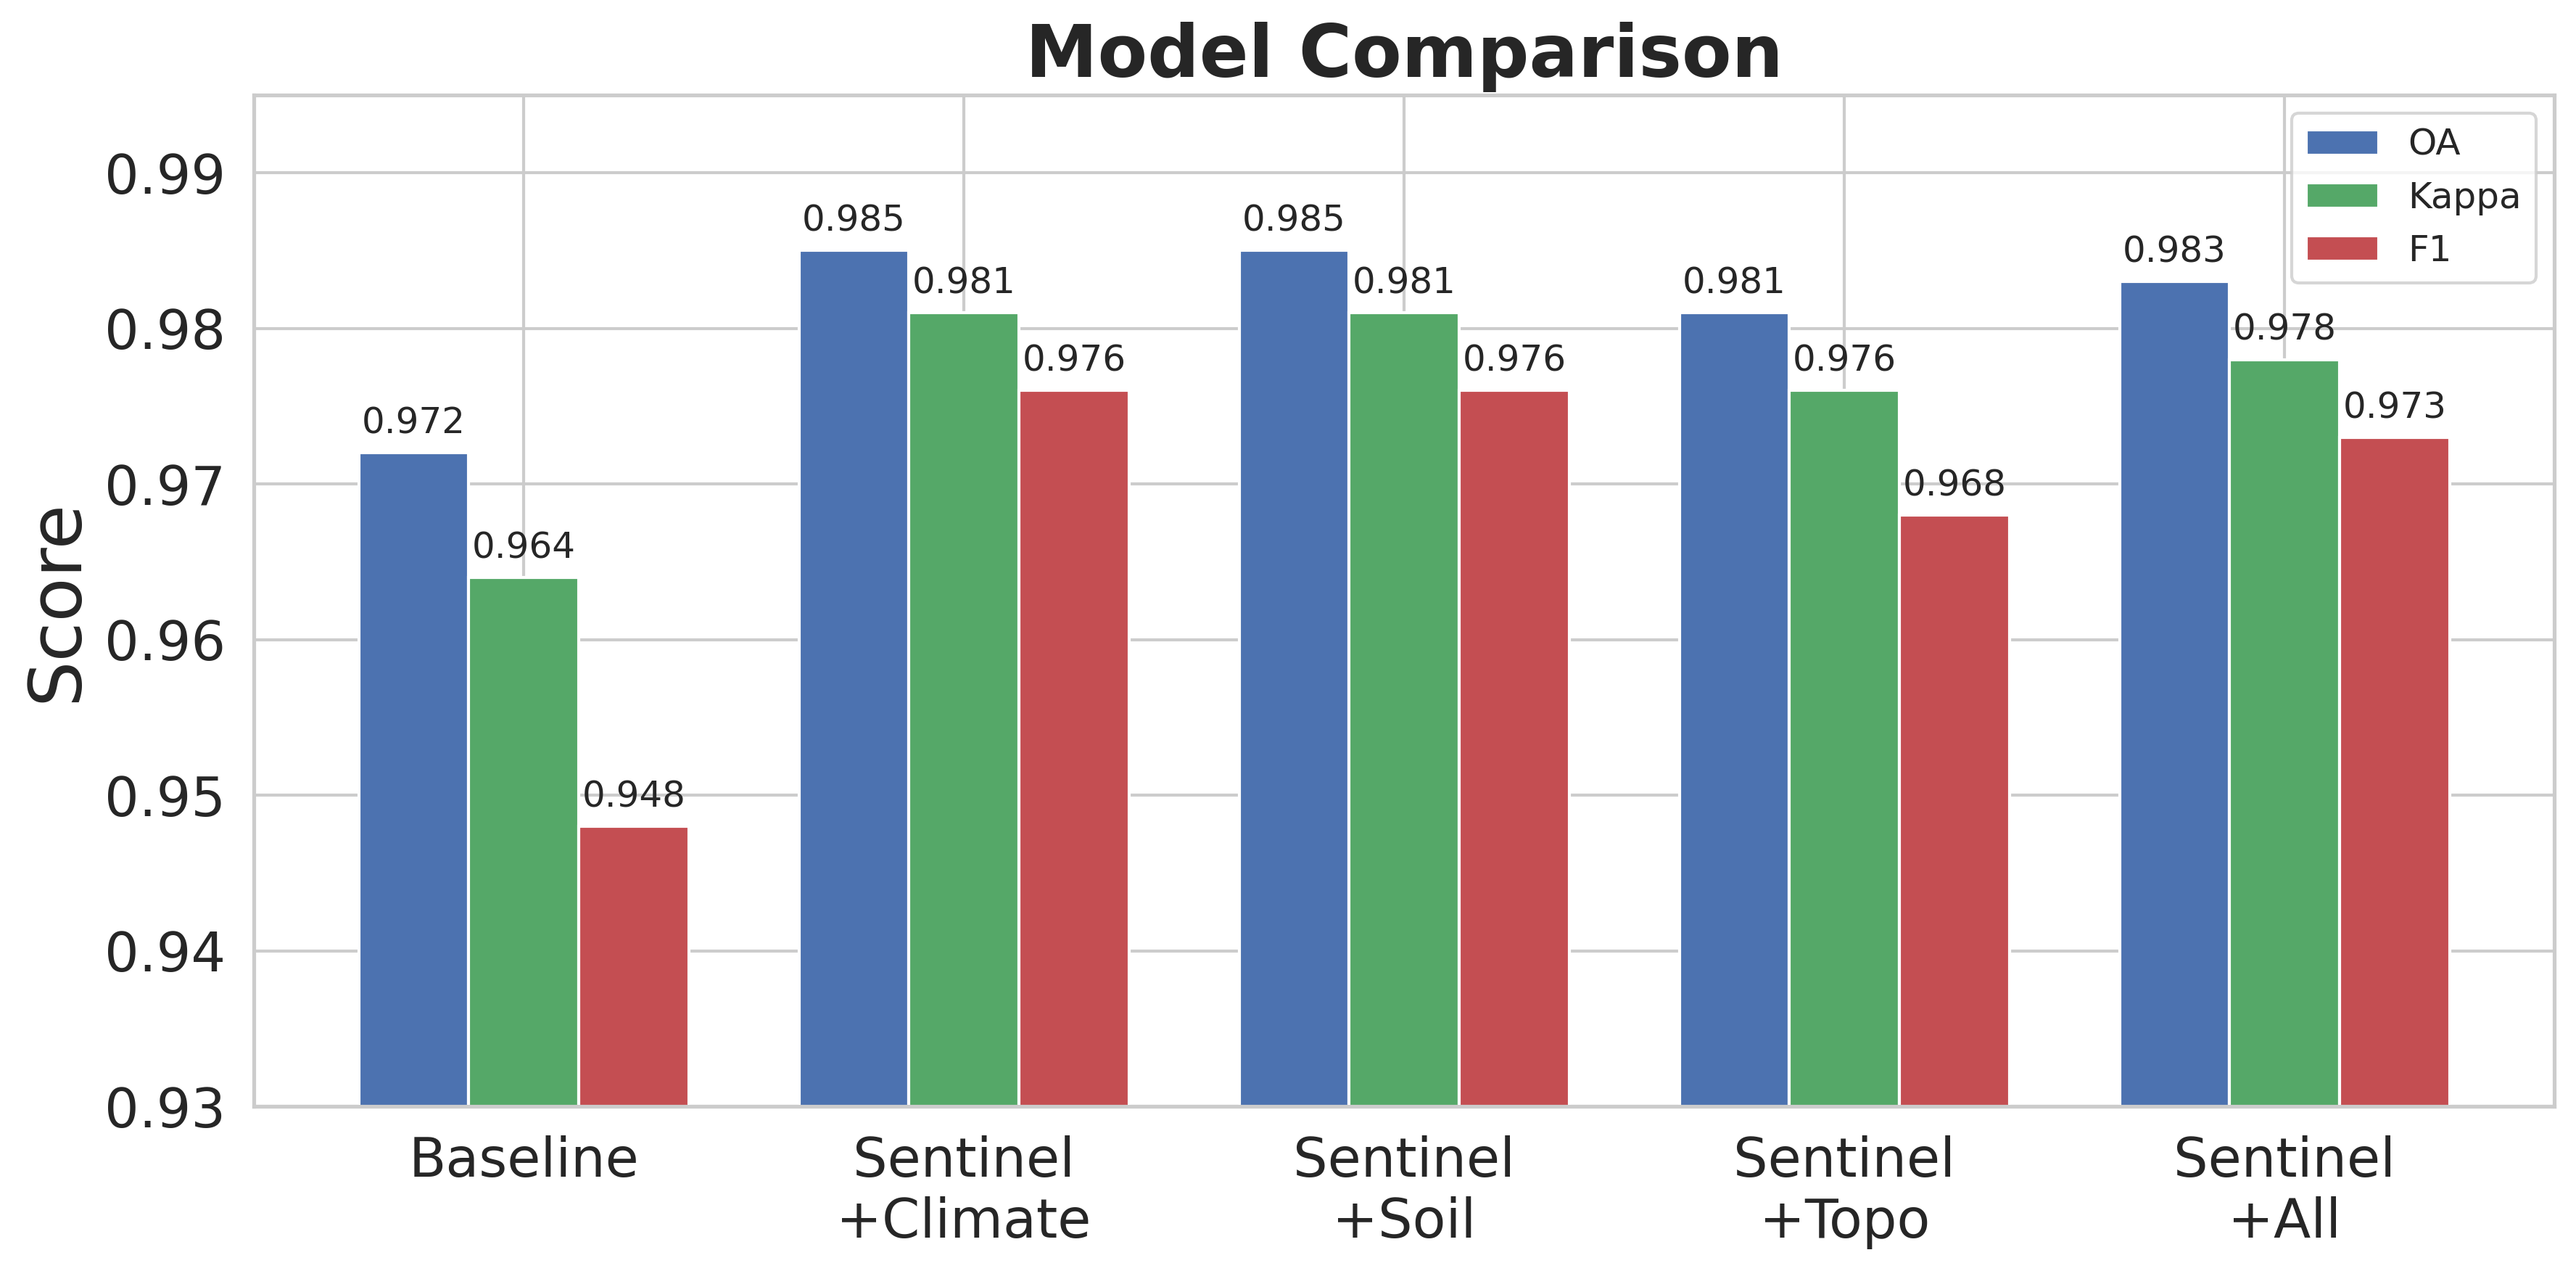

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

models = ['Baseline', 'Sentinel\n+Climate', 'Sentinel\n+Soil', 'Sentinel\n+Topo', 'Sentinel\n+All']
oa    = [0.972, 0.985, 0.985, 0.981, 0.983]
kappa = [0.964, 0.981, 0.981, 0.976, 0.978]
f1    = [0.948, 0.976, 0.976, 0.968, 0.973]

x = np.arange(len(models))
width = 0.25

sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

bars1 = ax.bar(x - width, oa,    width, label='OA',    color='#4C72B0')
bars2 = ax.bar(x,         kappa, width, label='Kappa', color='#55A868')
bars3 = ax.bar(x + width, f1,    width, label='F1',    color='#C44E52')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=12)

ax.set_ylim(0.93, 0.995)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=18)
ax.set_ylabel('Score', fontsize=24)
ax.set_title('Model Comparison', fontsize=24, fontweight='bold')
ax.legend(fontsize=12)
ax.tick_params(axis='y', labelsize=18)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

#**CONCLUSION**
we conclude that adding covariates data can improve performance, but only if that data provides genuinely useful information. Adding all available sources is therefore not always the best strategy. In general covariates can improve model metrics, the most useful of which are climate and soil data, with topography also showing slight improvement.



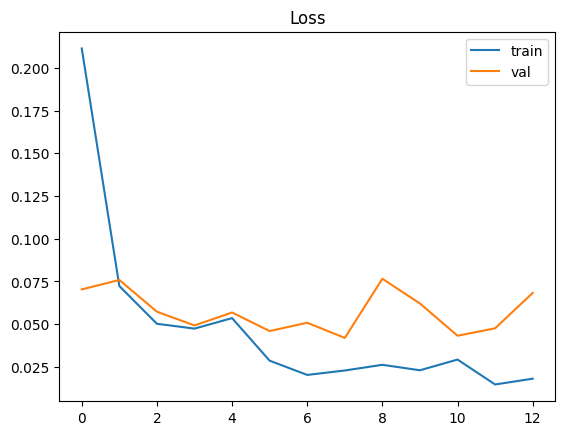

In [ ]:
if 'sentinel+all' in results:
    history = results['sentinel+all']['history']

    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.legend()
    plt.title("Loss")
    plt.show()
else:
    print("Run the training cell first. The key 'sentinel+all' is not available yet.")


# **Exploratory Analysis**

In this section, we study the selected environmental covariates kept for Part 2 through a simple EDA:
- data quality
- class distribution
- regional analysis
- crop-level analysis
- correlation analysis


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

climate_bands = ['temperature_2m', 'temperature_2m_max', 'temperature_2m_min',
                 'total_precipitation_sum', 'u_component_of_wind_10m', 'v_component_of_wind_10m']
climate_cols  = [c for c in dataset.columns if any(c.endswith(b) for b in climate_bands)]
soil_cols     = [c for c in dataset.columns if c.startswith('soil_')]
topo_cols     = [c for c in dataset.columns if c.startswith('topo_')]

climate_cols  = sorted(climate_cols, key=lambda c: int(c.split('_')[0]))

regions = dataset['region'].unique()


In [ ]:
# CLIAMTE ------------------
temp_min_cols = [c for c in climate_cols if c.endswith('temperature_2m_min')]
temp_max_cols = [c for c in climate_cols if c.endswith('temperature_2m_max')]
precip_cols   = [c for c in climate_cols if c.endswith('total_precipitation_sum')]
u_cols        = [c for c in climate_cols if c.endswith('u_component_of_wind_10m')]
v_cols        = [c for c in climate_cols if c.endswith('v_component_of_wind_10m')]

climate_summary = []
for state, grp in dataset.groupby('state'):
    climate_summary.append({
        'state':               state,
        'min temperature (C)': round(grp[temp_min_cols].values.min() - 273.15, 2),
        'max temperature (C)': round(grp[temp_max_cols].values.max() - 273.15, 2),
        'avg temperature (C)': round(grp[[c for c in climate_cols if c.endswith('temperature_2m')]].values.mean() - 273.15, 2),
        'avg precip (mm)':     round(grp[precip_cols].values.mean() * 1000, 2),
        'avg wind (m/s)':      round(np.sqrt(grp[u_cols].values**2 + grp[v_cols].values**2).mean(), 2),
    })

pd.DataFrame(climate_summary)

,state,min temperature (C),max temperature (C),avg temperature (C),avg precip (mm),avg wind (m/s)
0,arkansas,-10.28,33.05,17.12,3.7,1.22
1,california,3.59,41.70,19.14,1.6,1.18


In [ ]:
# SOIL ------------------
soil_summary = []
for state, grp in dataset.groupby('state'):
    soil_summary.append({
        'state':       state,
        'avg soil ph': grp['soil_ph'].mean().round(2),
        'avg soil organic carbon': grp['soil_oc'].mean().round(2),
    })

pd.DataFrame(soil_summary)

,state,avg soil ph,avg soil organic carbon
0,arkansas,58.77,2.37
1,california,72.71,3.43


In [ ]:
# TOPOGRAPHY ------------------
topo_summary = []
for state, grp in dataset.groupby('state'):
    topo_summary.append({
        'state':      state,
        'avg elevation':   grp['topo_elev'].mean().round(2),
        'avg slope':  grp['topo_slope'].mean().round(2),
    })

pd.DataFrame(topo_summary)

,state,avg elevation,avg slope
0,arkansas,61.40,2.08
1,california,52.85,2.10


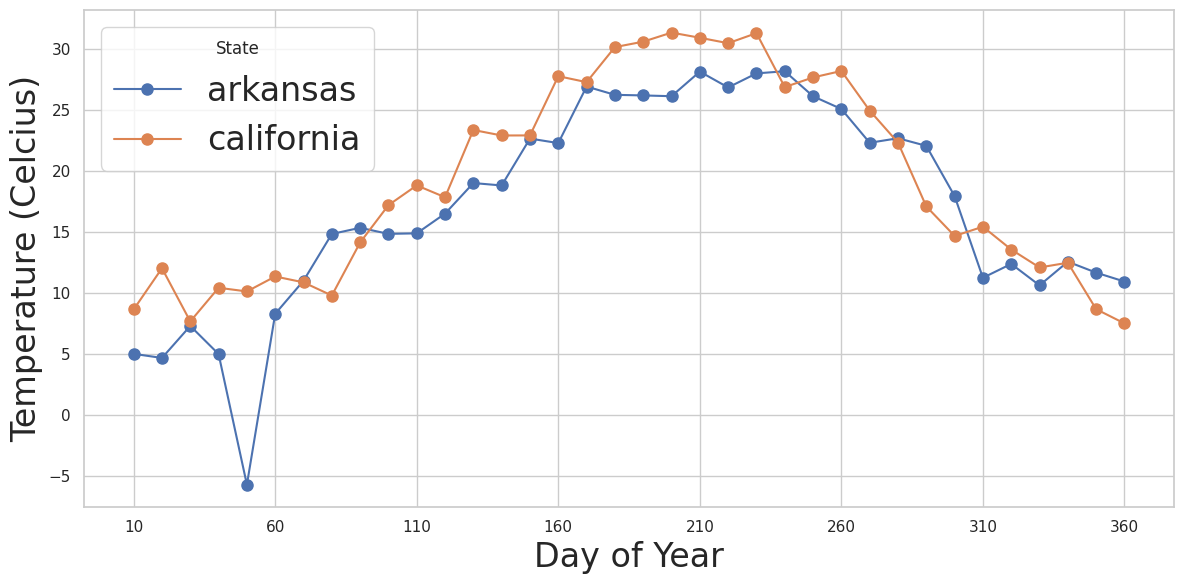

In [ ]:
dataset['state'] = dataset['region'].str.extract(r'(california|arkansas)')

days = [(int(c.split('_')[0]) + 1) * 10 for c in climate_cols if c.endswith('temperature_2m')]
temp_cols = [c for c in climate_cols if c.endswith('temperature_2m')]

fig, ax = plt.subplots(figsize=(12, 6))

for state, grp in dataset.groupby('state'):
    mean_vals = grp[temp_cols].mean(axis=0).values - 273.15
    ax.plot(days, mean_vals, marker='o', markersize=8, label=state)

ax.set_xlabel('Day of Year', fontsize = 24)
ax.set_ylabel('Temperature (Celcius)', fontsize = 24)
ax.set_xticks(range(10, 361, 50))
ax.legend(title='State', fontsize = 24)
ax.grid(True)

plt.tight_layout()
plt.savefig("temperature_dist.png", dpi=300)
plt.show()

# **graphs**

## 1. Data quality check


In [ ]:
print("Dataset shape:", dataset.shape)

if len(selected_covariates) == 0:
    print("No selected covariates found in the dataset.")
else:
    missing_values = dataset[selected_covariates].isna().sum().to_frame("missing_values")
    display(missing_values)

    display(dataset[selected_covariates].describe().T)


Dataset shape: (11350, 584)


,missing_values
topo_elev,0
topo_aspect,0
topo_slope,0
soil_oc,0
soil_ph,0


,count,mean,std,min,25%,50%,75%,max
topo_elev,11350.0,57.971982,26.571087,19.0,33.000000,45.000000,73.000000,127.000000
topo_aspect,11350.0,146.345522,107.494636,-0.0,50.982068,139.174896,232.364044,352.963196
topo_slope,11350.0,2.084130,1.616021,0.0,1.144347,1.518586,2.576092,32.378311
soil_oc,11350.0,2.791806,1.331648,0.0,2.000000,2.000000,3.000000,17.000000
soil_ph,11350.0,64.362731,7.239637,52.0,58.000000,61.000000,72.000000,80.000000


## 2. Class distribution


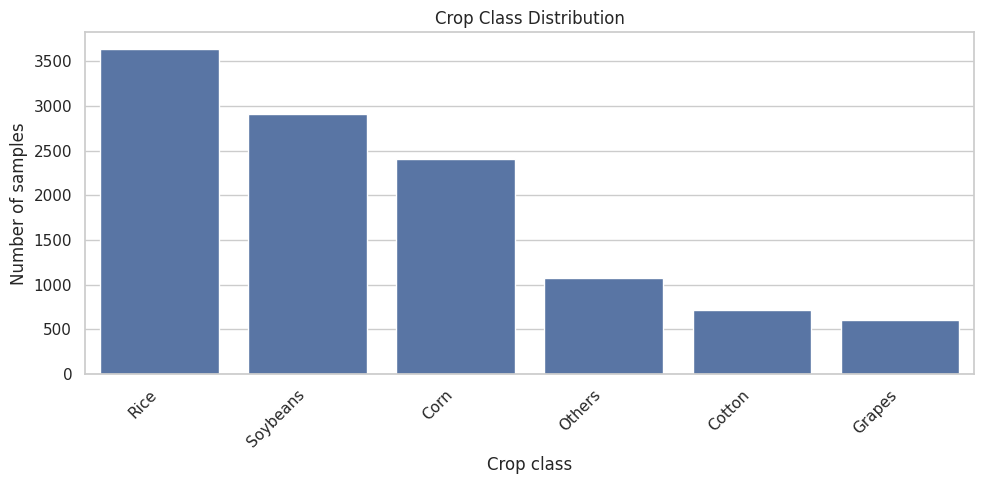

In [ ]:
dataset["crop_name"] = dataset["cropland"].map(CLASS_NAMES).fillna("Others")
crop_order = dataset["crop_name"].value_counts().index

plt.figure(figsize=(10, 5))
sns.countplot(data=dataset, x="crop_name", order=crop_order)
plt.title("Crop Class Distribution")
plt.xlabel("Crop class")
plt.ylabel("Number of samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 3. Regional analysis

Here we compare the average environmental covariate values between the four study regions.


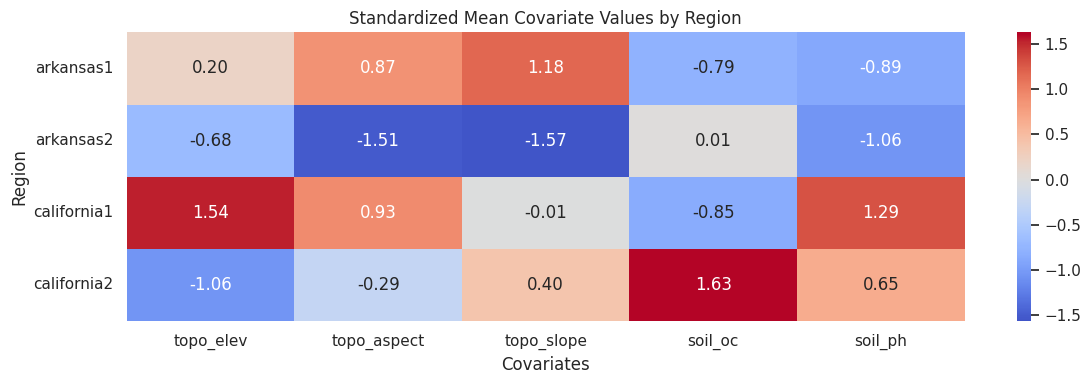

In [ ]:
if len(selected_covariates) == 0:
    print("No selected covariates found in the dataset.")
else:
    region_order = ["arkansas1", "arkansas2", "california1", "california2"]
    region_means_scaled = standardized_group_means(
        dataset,
        group_col="region",
        covariates=selected_covariates,
        order=region_order,
    )

    plt.figure(figsize=(12, max(4, 0.8 * len(region_means_scaled))))
    sns.heatmap(
        region_means_scaled,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f"
    )
    plt.title("Standardized Mean Covariate Values by Region")
    plt.xlabel("Covariates")
    plt.ylabel("Region")
    plt.tight_layout()
    plt.show()


## 4. Crop-level analysis

This heatmap compares the average covariate profile of the six main crop classes.


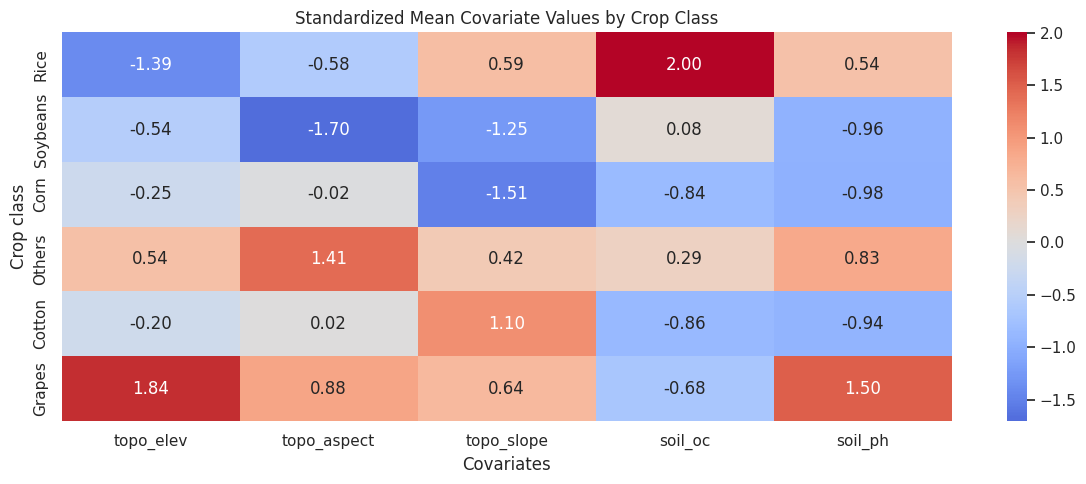

In [ ]:
if len(selected_covariates) == 0:
    print("No selected covariates found in the dataset.")
else:
    main_classes = dataset["crop_name"].value_counts().head(6).index
    crop_df = dataset[dataset["crop_name"].isin(main_classes)].copy()

    crop_means_scaled = standardized_group_means(
        crop_df,
        group_col="crop_name",
        covariates=selected_covariates,
        order=main_classes,
    )

    plt.figure(figsize=(12, max(5, 0.7 * len(crop_means_scaled))))
    sns.heatmap(
        crop_means_scaled,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f"
    )
    plt.title("Standardized Mean Covariate Values by Crop Class")
    plt.xlabel("Covariates")
    plt.ylabel("Crop class")
    plt.tight_layout()
    plt.show()


## 5. Correlation analysis

Finally, we check the correlation between the selected environmental covariates to see which variables are related to each other.


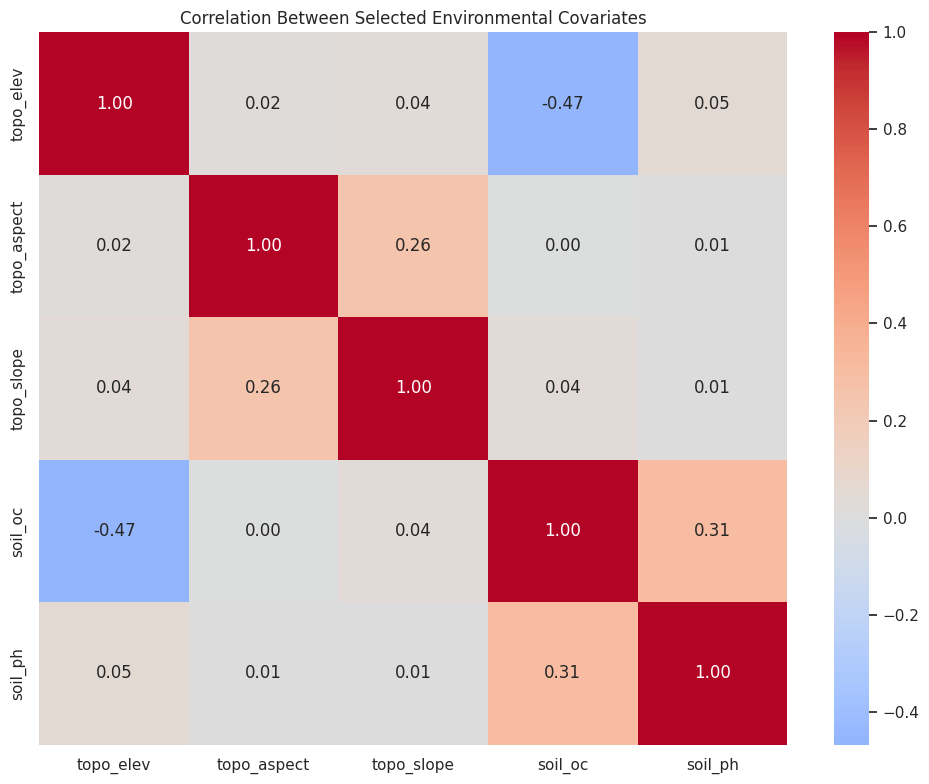

In [ ]:
if len(selected_covariates) == 0:
    print("No selected covariates found in the dataset.")
else:
    corr = dataset[selected_covariates].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f"
    )
    plt.title("Correlation Between Selected Environmental Covariates")
    plt.tight_layout()
    plt.show()
